In [44]:
import pandas as pd

In [45]:
df = pd.read_csv('drinks.csv')
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [46]:
df.shape

(193, 5)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    object 
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 7.7+ KB


In [48]:
df.describe()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,193.000000,193.000000,193.000000
mean,106.160622,80.994819,49.450777,4.717098
std,101.143103,88.284312,79.697598,3.773298
min,0.000000,0.000000,0.000000,0.000000
25%,20.000000,4.000000,1.000000,1.300000
50%,76.000000,56.000000,8.000000,4.200000
75%,188.000000,128.000000,59.000000,7.200000
max,376.000000,438.000000,370.000000,14.400000


In [49]:
df.isnull().sum()

country                         0
beer_servings                   0
spirit_servings                 0
wine_servings                   0
total_litres_of_pure_alcohol    0
dtype: int64

In [50]:
#Top 10 countries with highest consumption of total alcohol

top_total = df.sort_values("total_litres_of_pure_alcohol", ascending=False).head(10)

print(top_total[["country", "total_litres_of_pure_alcohol"]])

                country  total_litres_of_pure_alcohol
15              Belarus                          14.4
98            Lithuania                          12.9
3               Andorra                          12.4
68              Grenada                          11.9
61               France                          11.8
45       Czech Republic                          11.8
141  Russian Federation                          11.5
99           Luxembourg                          11.4
155            Slovakia                          11.4
81              Ireland                          11.4


In [51]:
#Coutnries with no alcohol consumption

zero_alcohol = df[df["total_litres_of_pure_alcohol"] == 0]

print(zero_alcohol[["country", "total_litres_of_pure_alcohol"]])

              country  total_litres_of_pure_alcohol
0         Afghanistan                           0.0
13         Bangladesh                           0.0
46        North Korea                           0.0
79               Iran                           0.0
90             Kuwait                           0.0
97              Libya                           0.0
103          Maldives                           0.0
106  Marshall Islands                           0.0
107        Mauritania                           0.0
111            Monaco                           0.0
128          Pakistan                           0.0
147        San Marino                           0.0
158           Somalia                           0.0


In [52]:
import matplotlib.pyplot as plt

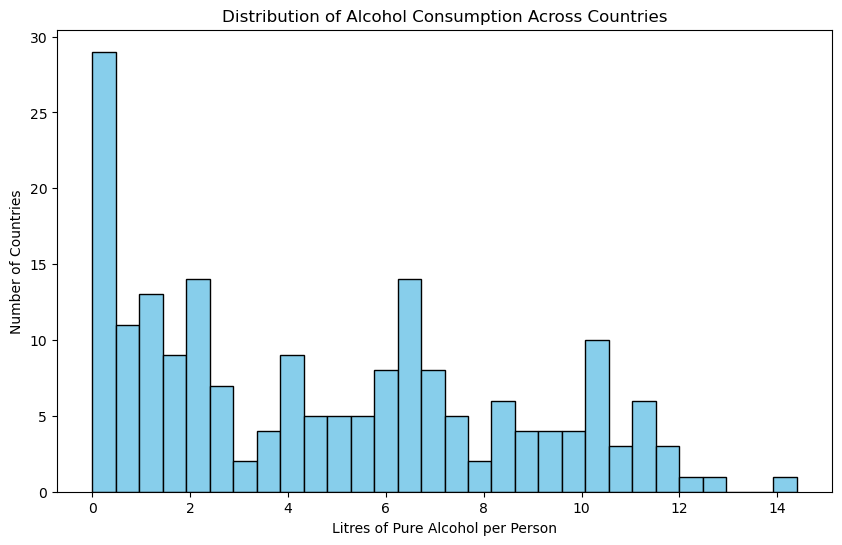

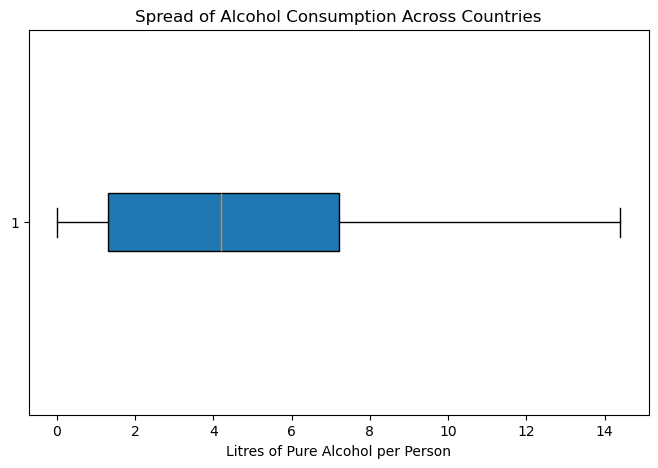

In [53]:
plt.figure(figsize=(10,6))
plt.hist(df["total_litres_of_pure_alcohol"], bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Litres of Pure Alcohol per Person")
plt.ylabel("Number of Countries")
plt.title("Distribution of Alcohol Consumption Across Countries")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["total_litres_of_pure_alcohol"], vert=False, patch_artist=True)
plt.xlabel("Litres of Pure Alcohol per Person")
plt.title("Spread of Alcohol Consumption Across Countries")
plt.show()

In [54]:
#Average worldwide alcohol consumption
world_avg = df["total_litres_of_pure_alcohol"].mean()

print("Average worldwide alcohol consumption:", round(world_avg, 2), "litres of pure alcohol")

Average worldwide alcohol consumption: 4.72 litres of pure alcohol


In [55]:
#Average of beer, spirit, wine servings and the most globaly consumed type of alcohol
avg_beer = df["beer_servings"].mean()
avg_spirits = df["spirit_servings"].mean()
avg_wine = df["wine_servings"].mean()

print("Average Beer Servings:", round(avg_beer, 2))
print("Average Spirit Servings:", round(avg_spirits, 2))
print("Average Wine Servings:", round(avg_wine, 2))

consumption = {
    "Beer": avg_beer,
    "Spirits": avg_spirits,
    "Wine": avg_wine
}

most_consumed = max(consumption, key=consumption.get)
print("Globally, the most consumed type of alcohol is:", most_consumed)


Average Beer Servings: 106.16
Average Spirit Servings: 80.99
Average Wine Servings: 49.45
Globally, the most consumed type of alcohol is: Beer


In [56]:
from scipy.stats import zscore

In [57]:
df["zscore"] = zscore(df["total_litres_of_pure_alcohol"])

outliers_z = df[df["zscore"].abs() > 2]

print("Extreme alcohol consumers (Z-score method):")
print(outliers_z[["country", "total_litres_of_pure_alcohol", "zscore"]])


Extreme alcohol consumers (Z-score method):
      country  total_litres_of_pure_alcohol    zscore
3     Andorra                          12.4  2.041419
15    Belarus                          14.4  2.572838
98  Lithuania                          12.9  2.174274


In [58]:
Q1 = df["total_litres_of_pure_alcohol"].quantile(0.25)
Q3 = df["total_litres_of_pure_alcohol"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.0 * IQR
upper_bound = Q3 + 1.0 * IQR

outliers_iqr = df[(df["total_litres_of_pure_alcohol"] < lower_bound) |
                  (df["total_litres_of_pure_alcohol"] > upper_bound)]

print(outliers_iqr[["country", "total_litres_of_pure_alcohol"]])


    country  total_litres_of_pure_alcohol
15  Belarus                          14.4


In [59]:
#Top 10 Countries by Beer, Wine, and Sprirt Consumption
top_beer = df.sort_values("beer_servings", ascending=False).head(10)
print("Top 10 Countries by Beer Consumption:")
print(top_beer[["country", "beer_servings"]], "\n")

top_wine = df.sort_values("wine_servings", ascending=False).head(10)
print("Top 10 Countries by Wine Consumption:")
print(top_wine[["country", "wine_servings"]], "\n")

top_spirits = df.sort_values("spirit_servings", ascending=False).head(10)
print("Top 10 Countries by Spirit Consumption:")
print(top_spirits[["country", "spirit_servings"]], "\n")


Top 10 Countries by Beer Consumption:
            country  beer_servings
117         Namibia            376
45   Czech Republic            361
62            Gabon            347
65          Germany            346
98        Lithuania            343
135          Poland            343
188       Venezuela            333
81          Ireland            313
129           Palau            306
140         Romania            297 

Top 10 Countries by Wine Consumption:
               country  wine_servings
61              France            370
136           Portugal            339
3              Andorra            312
166        Switzerland            280
48             Denmark            278
156           Slovenia            276
99          Luxembourg            271
42             Croatia            254
83               Italy            237
55   Equatorial Guinea            233 

Top 10 Countries by Spirit Consumption:
                country  spirit_servings
68              Grenada             

In [60]:
#Countries prefer beer over wine and spirits
beer_pref = df[(df["beer_servings"] > df["wine_servings"]) & 
               (df["beer_servings"] > df["spirit_servings"])]

print("Countries that prefer Beer over Wine and Spirits:")
print(beer_pref[["country", "beer_servings", "wine_servings", "spirit_servings"]])
print("Number of countries that prefer Beer over Wine and Spirits:", len(beer_pref))

Countries that prefer Beer over Wine and Spirits:
       country  beer_servings  wine_servings  spirit_servings
2      Algeria             25             14                0
4       Angola            217             45               57
8    Australia            261            212               72
9      Austria            279            191               75
16     Belgium            295            212               84
..         ...            ...            ...              ...
188  Venezuela            333              3              100
189    Vietnam            111              1                2
190      Yemen              6              0                0
191     Zambia             32              4               19
192   Zimbabwe             64              4               18

[101 rows x 4 columns]
Number of countries that prefer Beer over Wine and Spirits: 101


In [61]:
#Countries prefer wine over beer and spirits
wine_pref = df[(df["wine_servings"] > df["beer_servings"]) & 
               (df["wine_servings"] > df["spirit_servings"])]

print("Countries that prefer Wine over Beer and Spirits:")
print(wine_pref[["country", "beer_servings", "spirit_servings", "wine_servings"]])
print("Number of countries that prefer Wine over Beer and Spirits:", len(wine_pref))

Countries that prefer Wine over Beer and Spirits:
                 country  beer_servings  spirit_servings  wine_servings
3                Andorra            245              138            312
6              Argentina            193               25            221
35                 Chile            130              124            172
42               Croatia            230               87            254
48               Denmark            224               81            278
55     Equatorial Guinea             92                0            233
61                France            127              151            370
64               Georgia             52              100            149
67                Greece            133              112            218
83                 Italy             85               42            237
92                  Laos             62                0            123
99            Luxembourg            236              133            271
113           

In [62]:
#Countries prefer spirits over beer and wine
spirits_pref = df[(df["spirit_servings"] > df["beer_servings"]) & 
                  (df["spirit_servings"] > df["wine_servings"])]

print("Countries that prefer Spirits over Beer and Wine:")
print(spirits_pref[["country"]])
print("Number of countries that prefer Spirits over Beer and Wine:", len(spirits_pref))

Countries that prefer Spirits over Beer and Wine:
                          country
1                         Albania
5               Antigua & Barbuda
7                         Armenia
10                     Azerbaijan
11                        Bahamas
12                        Bahrain
14                       Barbados
15                        Belarus
21             Bosnia-Herzegovina
25                       Bulgaria
30                       Cambodia
36                          China
38                        Comoros
40                   Cook Islands
43                           Cuba
49                       Djibouti
50                       Dominica
54                    El Salvador
68                        Grenada
69                      Guatemala
71                  Guinea-Bissau
72                         Guyana
73                          Haiti
74                       Honduras
77                          India
82                         Israel
84                        Jamaic

In [63]:
# Global totals for each type of alcohol and their percentage
total_beer = df["beer_servings"].sum()
total_wine = df["wine_servings"].sum()
total_spirits = df["spirit_servings"].sum()

print("Total Beer Servings Worldwide:", total_beer)
print("Total Wine Servings Worldwide:", total_wine)
print("Total Spirits Servings Worldwide:", total_spirits, "\n")

total_all = total_beer + total_wine + total_spirits

beer_pct = (total_beer / total_all) * 100
wine_pct = (total_wine / total_all) * 100
spirits_pct = (total_spirits / total_all) * 100

print(f"Beer: {beer_pct:.2f}%")
print(f"Wine: {wine_pct:.2f}%")
print(f"Spirits: {spirits_pct:.2f}%")


Total Beer Servings Worldwide: 20489
Total Wine Servings Worldwide: 9544
Total Spirits Servings Worldwide: 15632 

Beer: 44.87%
Wine: 20.90%
Spirits: 34.23%


In [64]:
p90 = df["total_litres_of_pure_alcohol"].quantile(0.90)
high_consumers = df[df["total_litres_of_pure_alcohol"] > p90]

print("90th percentile threshold:", round(p90, 2))
print("Number of high-consumption countries:", len(high_consumers))
print("High-consumption countries:")
print(high_consumers[["country", "total_litres_of_pure_alcohol"]])


90th percentile threshold: 10.4
Number of high-consumption countries: 17
High-consumption countries:
                country  total_litres_of_pure_alcohol
3               Andorra                          12.4
15              Belarus                          14.4
16              Belgium                          10.5
45       Czech Republic                          11.8
61               France                          11.8
65              Germany                          11.3
68              Grenada                          11.9
75              Hungary                          11.3
81              Ireland                          11.4
93               Latvia                          10.5
98            Lithuania                          12.9
99           Luxembourg                          11.4
135              Poland                          10.9
136            Portugal                          11.0
141  Russian Federation                          11.5
155            Slovakia            

In [65]:
import seaborn as sns

Correlation Matrix:
                              beer_servings  wine_servings  spirit_servings  \
beer_servings                      1.000000       0.527172         0.458819   
wine_servings                      0.527172       1.000000         0.194797   
spirit_servings                    0.458819       0.194797         1.000000   
total_litres_of_pure_alcohol       0.835839       0.667598         0.654968   

                              total_litres_of_pure_alcohol  
beer_servings                                     0.835839  
wine_servings                                     0.667598  
spirit_servings                                   0.654968  
total_litres_of_pure_alcohol                      1.000000  


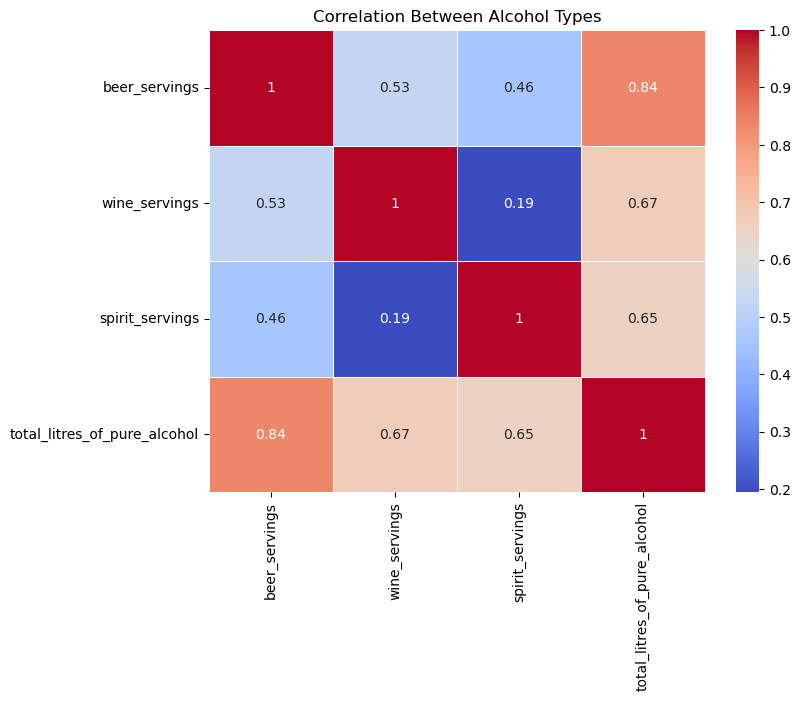

In [66]:
alcohol_types = df[["beer_servings", "wine_servings", "spirit_servings", "total_litres_of_pure_alcohol"]]

corr_matrix = alcohol_types.corr()

print("Correlation Matrix:")
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Alcohol Types")
plt.show()

Correlation (Beer vs Total Alcohol): 0.836


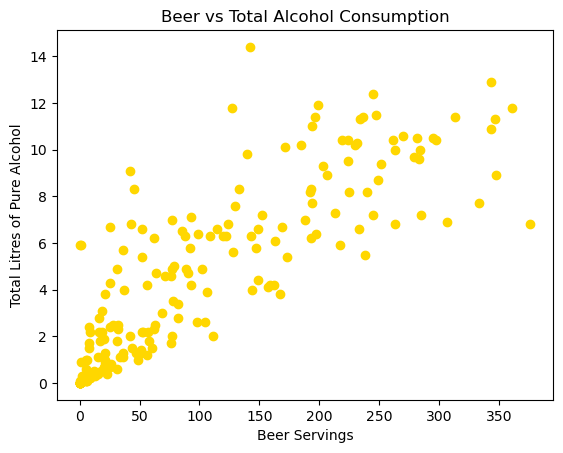

In [67]:
# Correlation between beer and total alcohol
beer_corr = df["beer_servings"].corr(df["total_litres_of_pure_alcohol"])
print("Correlation (Beer vs Total Alcohol):", round(beer_corr, 3))

# Scatter plot
plt.scatter(df["beer_servings"], df["total_litres_of_pure_alcohol"], color="gold")
plt.xlabel("Beer Servings")
plt.ylabel("Total Litres of Pure Alcohol")
plt.title("Beer vs Total Alcohol Consumption")
plt.show()


Correlation (Wine vs Total Alcohol): 0.668


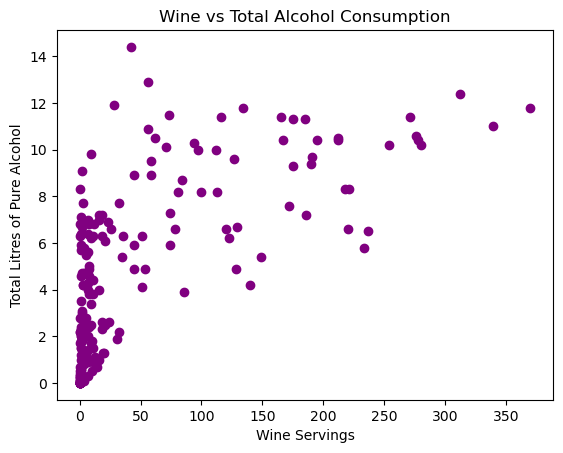

In [68]:
# Correlation between wine and total alcohol
wine_corr = df["wine_servings"].corr(df["total_litres_of_pure_alcohol"])
print("Correlation (Wine vs Total Alcohol):", round(wine_corr, 3))

# Scatter plot
plt.scatter(df["wine_servings"], df["total_litres_of_pure_alcohol"], color="purple")
plt.xlabel("Wine Servings")
plt.ylabel("Total Litres of Pure Alcohol")
plt.title("Wine vs Total Alcohol Consumption")
plt.show()


Correlation (Spirits vs Total Alcohol): 0.655


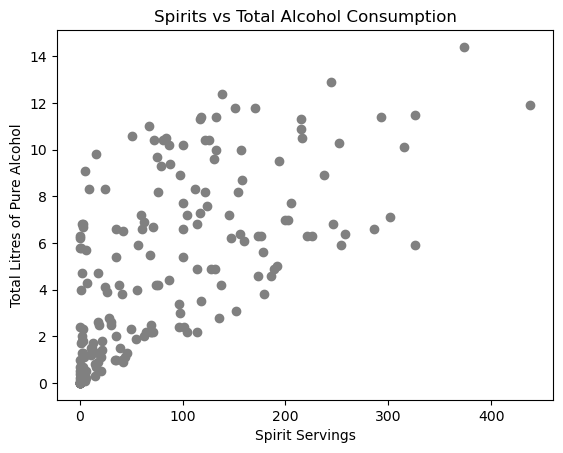

In [69]:
# Correlation between spirits and total alcohol
spirits_corr = df["spirit_servings"].corr(df["total_litres_of_pure_alcohol"])
print("Correlation (Spirits vs Total Alcohol):", round(spirits_corr, 3))

# Scatter plot
plt.scatter(df["spirit_servings"], df["total_litres_of_pure_alcohol"], color="gray")
plt.xlabel("Spirit Servings")
plt.ylabel("Total Litres of Pure Alcohol")
plt.title("Spirits vs Total Alcohol Consumption")
plt.show()


In [70]:
# Determine preferred alcohol type for each country
def preferred_type(row):
    if row["total_litres_of_pure_alcohol"] == 0:
        return "No Alcohol"
    elif (row["beer_servings"] > row["wine_servings"]) and (row["beer_servings"] > row["spirit_servings"]):
        return "Beer"
    elif (row["wine_servings"] > row["beer_servings"]) and (row["wine_servings"] > row["spirit_servings"]):
        return "Wine"
    elif (row["spirit_servings"] > row["beer_servings"]) and (row["spirit_servings"] > row["wine_servings"]):
        return "Spirits"
    else:
        return "Mixed/Equal"

# Apply function to dataset
df["preferred_alcohol"] = df.apply(preferred_type, axis=1)

# Count how many countries prefer each type
preference_counts = df["preferred_alcohol"].value_counts()
print("Alcohol preference distribution across countries:")
print(preference_counts)

# Show sample of countries by preference
for pref in ["Beer", "Wine", "Spirits", "No Alcohol"]:
    print(f"\nCountries preferring {pref}:")
    print(df[df["preferred_alcohol"] == pref]["country"].head(10).tolist())


Alcohol preference distribution across countries:
preferred_alcohol
Beer          101
Spirits        59
Wine           20
No Alcohol     13
Name: count, dtype: int64

Countries preferring Beer:
['Algeria', 'Angola', 'Australia', 'Austria', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Botswana']

Countries preferring Wine:
['Andorra', 'Argentina', 'Chile', 'Croatia', 'Denmark', 'Equatorial Guinea', 'France', 'Georgia', 'Greece', 'Italy']

Countries preferring Spirits:
['Albania', 'Antigua & Barbuda', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Barbados', 'Belarus', 'Bosnia-Herzegovina', 'Bulgaria']

Countries preferring No Alcohol:
['Afghanistan', 'Bangladesh', 'North Korea', 'Iran', 'Kuwait', 'Libya', 'Maldives', 'Marshall Islands', 'Mauritania', 'Monaco']


In [71]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [72]:
# StandardScaler scales beer, wine, and spirit values so they are on the same scale.
# This prevents one type of alcohol with larger numbers from dominating the clustering.

X = df[["beer_servings", "wine_servings", "spirit_servings"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [73]:
# KMeans is an unsupervised machine learning algorithm that groups countries into clusters.
# Each cluster represents a distinct drinking pattern based on alcohol consumption.
# The cluster column stores the group number (0, 1, or 2) assigned to each country.
# This shows which drinking pattern each country belongs to.
 
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(df[["country", "beer_servings", "wine_servings", "spirit_servings", "cluster"]].head(10))


             country  beer_servings  wine_servings  spirit_servings  cluster
0        Afghanistan              0              0                0        1
1            Albania             89             54              132        0
2            Algeria             25             14                0        1
3            Andorra            245            312              138        2
4             Angola            217             45               57        2
5  Antigua & Barbuda            102             45              128        0
6          Argentina            193            221               25        2
7            Armenia             21             11              179        0
8          Australia            261            212               72        2
9            Austria            279            191               75        2


C:\Users\Fate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [74]:
# Cluster profiles show the average beer, wine, and spirit servings for each cluster.
# This helps interpret what each cluster represents (e.g., spirit-heavy, beer/wine, or low/no alcohol).

cluster_profiles = df.groupby("cluster")[["beer_servings", "wine_servings", "spirit_servings"]].mean()
print(cluster_profiles)

         beer_servings  wine_servings  spirit_servings
cluster                                               
0           163.255814      32.093023       207.930233
1            40.572727       9.654545        26.300000
2           225.150000     177.550000        94.950000


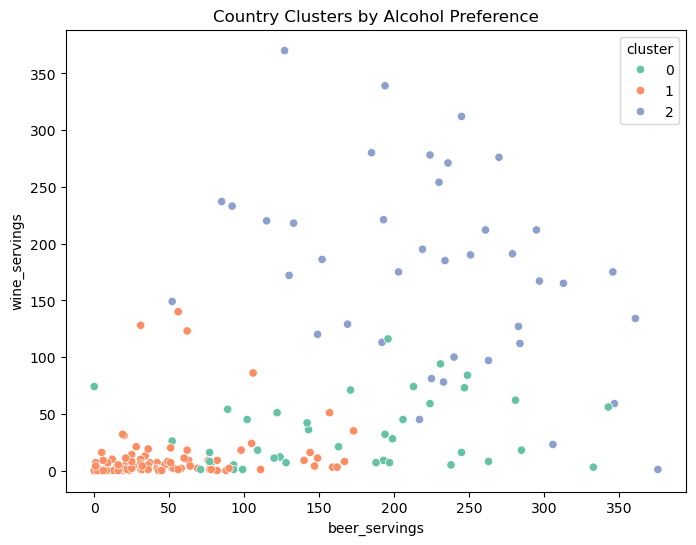

In [75]:
# The scatter plot visualizes countries by beer vs wine consumption, colored by cluster.
# This makes the clusters easy to see and compare visually.

plt.figure(figsize=(8,6))
sns.scatterplot(x="beer_servings", y="wine_servings", hue="cluster", data=df, palette="Set2")
plt.title("Country Clusters by Alcohol Preference")
plt.show()


C:\Users\Fate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Fate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Fate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Fate\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

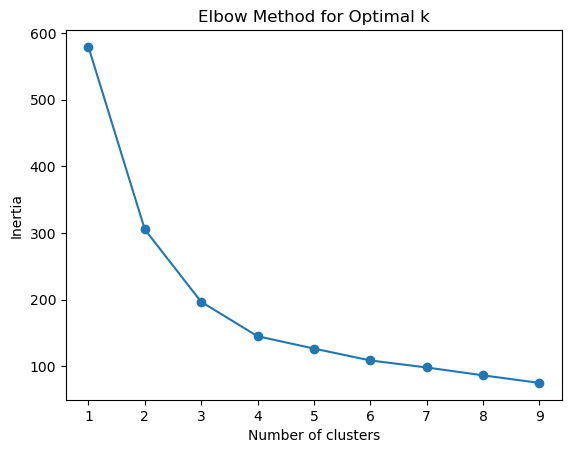

In [76]:
# The Elbow Method tests different numbers of clusters and plots inertia (variance within clusters).
# The elbow point shows the optimal number of clusters where adding more clusters gives little improvement.

inertia = []
for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [ ]:
# The warning about KMeans and MKL on Windows is a system-level issue.
# It means memory may not be released efficiently, but results remain correct and can be safely ignored.
